# Clips around behavior events, and frames for labeling

`video_clips` on a public session with dropped frames:
`behavior_816212_2025-12-05_13-47-41`, bottom camera (500 Hz; 187,024 of
2.9 million exposures were not saved). Steps:

1. corrected frame times (`video_timing_qc`);
2. picking events (go cues, first lick after each go cue): plain numpy, not in
   the library;
3. events → frame windows (`video_alignment.event_frame_ranges`);
4. windows → clips (`video_clips.cut_clips`), straight from the S3 MP4 over
   HTTPS;
5. clips → PNGs for DeepLabCut (`select_frames`), context frames for
   Lightning Pose (`add_context_frames`), labels → source frames and behavior
   time (`labeled_frames_table`).

Needs the `video-clips` extra and ffmpeg. Downloads the video CSV (112 MB),
the trigger log (38 MB) and the session JSON (7 MB) to `video_clips_data/`;
the MP4 (5.5 GB) is only read where clips are cut. In practice, check first
that the screen (`video_screen`) says to use the camera.

In [1]:
import json
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from aind_dynamic_foraging_behavior_video_analysis import video_alignment as va
from aind_dynamic_foraging_behavior_video_analysis import video_clips as vc
from aind_dynamic_foraging_behavior_video_analysis import video_timing_qc as vtq

BUCKET = "https://aind-open-data.s3.us-west-2.amazonaws.com"
session = "behavior_816212_2025-12-05_13-47-41"
camera = "bottom_camera"
mp4 = f"{BUCKET}/{session}/behavior-videos/{camera}.mp4"
files = {
    "video_csv": f"{session}/behavior-videos/{camera}.csv",
    "trigger_log": f"{session}/behavior/raw.harp/BehaviorEvents/Event_94.bin",
    "behavior_json": f"{session}/behavior/816212_2025-12-05_13-47-41.json",
}
data = Path("video_clips_data")
local = {}
for name, key in files.items():
    local[name] = data / key
    if not local[name].exists():
        local[name].parent.mkdir(parents=True, exist_ok=True)
        urllib.request.urlretrieve(f"{BUCKET}/{key}", local[name])
work = data / "work"  # clips and labeled-data written below

## 1. Corrected frame times

Row *i* of the CSV is frame *i* of the MP4. Its raw Harp column pairs frames
with triggers in arrival order, so after each drop every later frame carries
an earlier trigger's time. `correct_video_timing` re-indexes them through the
trigger log.

In [2]:
timing = vtq.load_video_timing(local["video_csv"])
log = vtq.read_harp_trigger_log(local["trigger_log"])
print("verdict:", vtq.timing_verdict(vtq.check_video_timing(timing, trigger_times=log)))
timing = vtq.correct_video_timing(timing, trigger_times=log)
harp = timing["harp_time"].to_numpy()
lag = harp - timing["harp_time_raw"].to_numpy()
print(f"{len(timing):,} frames; raw Harp time is behind by {lag[-1]:.1f} s at the last frame")

verdict: use


2,748,281 frames; raw Harp time is behind by 374.0 s at the last frame


## 2. Picking events

Which events to clip is a choice per labeling round, so it stays out of the
library. Go cues come from the session JSON (`read_trial_times`, the same
values as the NWB trials table); licks from `B_LeftLickTime` /
`B_RightLickTime`, the NWB's `left_lick_time` / `right_lick_time`. Here: 4 go
cues spread over the session, the last one late (where the raw times are
furthest off), and the first lick after each.

In [3]:
trials = va.read_trial_times(local["behavior_json"])
go_cues = trials["goCue_start_time"].dropna().to_numpy()
go_cues = go_cues[np.linspace(0, len(go_cues) - 1, 4).round().astype(int)]

behavior = json.loads(local["behavior_json"].read_text())
licks = np.sort(np.r_[behavior["B_LeftLickTime"], behavior["B_RightLickTime"]])
after = np.searchsorted(licks, go_cues)
first_licks = licks[after[after < len(licks)]]

events = pd.DataFrame(
    {"event": ["go_cue"] * len(go_cues) + ["first_lick"] * len(first_licks),
     "time": np.r_[go_cues, first_licks]}
)
events

,event,time
0,go_cue,4314.092256
1,go_cue,5738.642304
2,go_cue,7242.544320
3,go_cue,8809.348096
4,first_lick,4314.434848
5,first_lick,5738.959584
6,first_lick,7242.940000
7,first_lick,8809.671776


## 3. Events → frame windows

`event_frame_ranges` gives the frames whose corrected Harp time is in
`[t - before, t + after)`. The same table slices any per-frame signal
(motion energy, pose predictions). For contrast, the raw column puts the
windows tens of thousands of frames too late.

In [4]:
ranges = va.event_frame_ranges(events["time"], harp, before=0.1, after=0.1)
raw = va.event_frame_ranges(events["time"], timing["harp_time_raw"], 0.1, 0.1)
ranges.assign(event=events["event"], frames_late_if_raw=raw.start_frame - ranges.start_frame)

,event_time,start_frame,n_frames,in_video,event,frames_late_if_raw
0,4314.092256,282170,94,True,go_cue,19215
1,5738.642304,949066,95,True,go_cue,64598
2,7242.544320,1653166,95,True,go_cue,112453
3,8809.348096,2386575,90,True,go_cue,162451
4,4314.434848,282331,96,True,first_lick,19225
5,5738.959584,949217,95,True,first_lick,64605
6,7242.940000,1653352,94,True,first_lick,112465
7,8809.671776,2386725,94,True,first_lick,162462


## 4. Frame windows → clips

Each clip is `<prefix>_f<start_frame:07d>.mp4` with a JSON sidecar; the
seek uses the MP4's own sample timestamps, read over HTTPS. Running the cell
again finds every clip (`exists`).

In [5]:
clips = vc.cut_clips(mp4, ranges, work / "clips", prefix=f"{session}_{camera}")
clips[["start_frame", "n_frames", "status", "clip"]]

,start_frame,n_frames,status,clip
0,282170,94,cut,video_clips_data/work/clips/behavior_816212_20...
1,949066,95,cut,video_clips_data/work/clips/behavior_816212_20...
2,1653166,95,cut,video_clips_data/work/clips/behavior_816212_20...
3,2386575,90,cut,video_clips_data/work/clips/behavior_816212_20...
4,282331,96,cut,video_clips_data/work/clips/behavior_816212_20...
5,949217,95,cut,video_clips_data/work/clips/behavior_816212_20...
6,1653352,94,cut,video_clips_data/work/clips/behavior_816212_20...
7,2386725,94,cut,video_clips_data/work/clips/behavior_816212_20...


In [6]:
vc.read_clip_info(clips["clip"].iloc[-1])

{'source_video': 'https://aind-open-data.s3.us-west-2.amazonaws.com/behavior_816212_2025-12-05_13-47-41/behavior-videos/bottom_camera.mp4',
 'start_frame': 2386725,
 'n_frames': 94,
 'versions': {'aind_dynamic_foraging_behavior_video_analysis': '0.3.0',
  'aind_video_utils': '0.7.0'}}

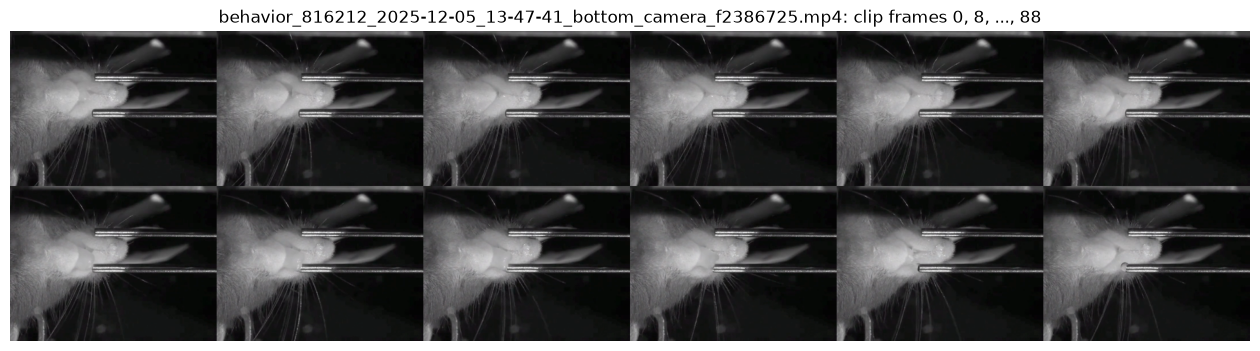

In [7]:
# One lick clip, every 8th frame (2 ms per frame, the lick at the centre).
import subprocess

clip = Path(clips["clip"].iloc[-1])
sheet = work / "sheet.png"
subprocess.run(
    ["ffmpeg", "-hide_banner", "-loglevel", "error", "-y", "-i", str(clip),
     "-vf", "select='not(mod(n\\,8))',scale=320:-1,tile=6x2",
     "-frames:v", "1", "-fps_mode", "passthrough", str(sheet)],
    check=True,
)
plt.figure(figsize=(16, 4.5))
plt.imshow(plt.imread(sheet), cmap="gray")
plt.title(f"{clip.name}: clip frames 0, 8, ..., 88")
plt.axis("off");

## 5. Frames for labeling

The clips are the videos of a DeepLabCut project. `select_frames` writes
PNGs to `labeled-data/<clip stem>/`, named as DLC's own extraction names
them, never within `margin` frames of either end.

In [8]:
labeled = work / "dlc_project" / "labeled-data"
for clip in clips["clip"].dropna().unique():
    picks = vc.select_frames(clip, 4, labeled, algorithm="kmeans")
    print(Path(clip).stem, picks)

behavior_816212_2025-12-05_13-47-41_bottom_camera_f0282170 [44 64 73 88]


behavior_816212_2025-12-05_13-47-41_bottom_camera_f0949066 [11 42 71 86]


behavior_816212_2025-12-05_13-47-41_bottom_camera_f1653166 [26 66 80 88]


behavior_816212_2025-12-05_13-47-41_bottom_camera_f2386575 [29 60 68 81]


behavior_816212_2025-12-05_13-47-41_bottom_camera_f0282331 [15 33 53 88]


behavior_816212_2025-12-05_13-47-41_bottom_camera_f0949217 [10 16 54 82]


behavior_816212_2025-12-05_13-47-41_bottom_camera_f1653352 [11 40 63 83]


behavior_816212_2025-12-05_13-47-41_bottom_camera_f2386725 [17 42 69 85]


After labeling in DLC, each folder has a `CollectedData_<scorer>.csv`.
Here a stand-in labels file marks the picked frames of one clip, to show the
last two steps.

In [9]:
folder = sorted(p for p in labeled.iterdir() if p.is_dir())[-1]
images = sorted(f"labeled-data/{folder.name}/{p.name}" for p in folder.glob("img*.png"))
rows = [["scorer", "", "", "me", "me"], ["bodyparts", "", "", "tongue", "tongue"],
        ["coords", "", "", "x", "y"]]
rows += [image.split("/") + ["0", "0"] for image in images]
(folder / "CollectedData_me.csv").write_text("\n".join(",".join(r) for r in rows) + "\n")
images

['labeled-data/behavior_816212_2025-12-05_13-47-41_bottom_camera_f2386725/img17.png',
 'labeled-data/behavior_816212_2025-12-05_13-47-41_bottom_camera_f2386725/img42.png',
 'labeled-data/behavior_816212_2025-12-05_13-47-41_bottom_camera_f2386725/img69.png',
 'labeled-data/behavior_816212_2025-12-05_13-47-41_bottom_camera_f2386725/img85.png']

Lightning Pose's context models read frames *t−2 … t+2* next to each
labeled frame *t* and silently use the centre frame for any that are
missing. `add_context_frames` writes them (after labeling, so they never
show up in DLC's labeling GUI).

In [10]:
written = vc.add_context_frames(labeled, work / "clips")
written.groupby("labeled_frame").clip_frame.apply(list)

labeled_frame
17    [15, 16, 18, 19]
42    [40, 41, 43, 44]
69    [67, 68, 70, 71]
85    [83, 84, 86, 87]
Name: clip_frame, dtype: object

Every label back to its source frame, from the names alone, then to
behavior time with one join. `source_frame` also indexes Lightning Pose
predictions for this camera.

In [11]:
labels = vc.labeled_frames_table(labeled)
labels["behavior_time"] = harp[labels["source_frame"]]
labels

,image,clip,prefix,clip_frame,start_frame,source_frame,behavior_time
0,labeled-data/behavior_816212_2025-12-05_13-47-...,behavior_816212_2025-12-05_13-47-41_bottom_cam...,behavior_816212_2025-12-05_13-47-41_bottom_camera,17,2386725,2386742,8809.607872
1,labeled-data/behavior_816212_2025-12-05_13-47-...,behavior_816212_2025-12-05_13-47-41_bottom_cam...,behavior_816212_2025-12-05_13-47-41_bottom_camera,42,2386725,2386767,8809.659872
2,labeled-data/behavior_816212_2025-12-05_13-47-...,behavior_816212_2025-12-05_13-47-41_bottom_cam...,behavior_816212_2025-12-05_13-47-41_bottom_camera,69,2386725,2386794,8809.717888
3,labeled-data/behavior_816212_2025-12-05_13-47-...,behavior_816212_2025-12-05_13-47-41_bottom_cam...,behavior_816212_2025-12-05_13-47-41_bottom_camera,85,2386725,2386810,8809.753888
